In [ ]:
from google.colab import drive, userdata
import os

# 1. Mount Drive
drive.mount('/content/drive')

# --- CONFIGURATION ---
# 🛑 Change this to the path of the SHARED folder containing everything
SHARED_FOLDER_PATH = "/content/drive/MyDrive/Colab_Notebooks/Training/linear_probing/AnySat"

GITHUB_USER = "MagicMorgigi"
REPO_NAME = "MA_AnySat_LP" # The empty repo you just created
TOKEN = userdata.get('MA_colab_github_PAT')
# --------------------

%cd "{SHARED_FOLDER_PATH}"

# 2. Initialize Git
!git init
!git config --global user.email "your_email@example.com"
!git config --global user.name "Your Name"

# 3. Create a STRICT .gitignore for the whole project
gitignore_content = """
# Ignore Colab/Python Cache
.ipynb_checkpoints/
__pycache__/

# Ignore Datasets (Add the names of your data folders here)
data/
datasets/

# Ignore Model Weights and Artifacts from your experiment subfolders
*.h5
*.pth
*.pt
*.pkl
*.weights
"""
with open('.gitignore', 'w') as f:
    f.write(gitignore_content)

# 4. Save and Push
!git add .
!git commit -m "Initial commit: Tracking all related notebooks and scripts"

remote_url = f"https://{TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git"
!git branch -M main
!git remote remove origin 2>/dev/null
!git remote add origin {remote_url}
!git push -u origin main

print("✅ Success! Your entire shared project folder is now on GitHub.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab_Notebooks/Training/linear_probing/AnySat
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/Colab_Notebooks/Training/linear_probing/AnySat/.git/
[master (root-commit) 6dda6da] Initial commit: Tracking all related notebooks and scripts
 35 files changed, 210 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 AS_LP_ExtractionTimeTestin

In [ ]:
from google.colab import userdata

# 1. Corrected Details
GITHUB_USER = "MagicMorgigi"  # Fixed the typo here!
REPO_NAME = "MA_AnySat_LP"
TOKEN = userdata.get('MA_colab_github_PAT')

# 2. Update the hidden link
remote_url = f"https://{TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git"
!git remote set-url origin {remote_url}

# 3. Try the push again
!git push -u origin main

Enumerating objects: 42, done.
Counting objects: 100% (42/42), done.
Delta compression using up to 2 threads
Compressing objects: 100% (41/41), done.
Writing objects: 100% (42/42), 8.77 MiB | 7.01 MiB/s, done.
Total 42 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), done.
To https://github.com/MagicMorgigi/MA_AnySat_LP.git
 * [new branch]      main -> main
Branch 'main' set up to track remote branch 'main' from 'origin'.


In [ ]:
# Cell 1: Setup, Reproducibility, and Drive Mount
!pip install -q pyarrow pandas tqdm scikit-learn matplotlib

import os
import gc
import time
import shutil
import random
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import IterableDataset, DataLoader
from google.colab import drive

# 1. Mount Google Drive IMMEDIATELY
print("Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)
print("✅ Google Drive Mounted Successfully.\n")

# 2. Ensure reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print(f"PyTorch Version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'}")

Mounting Google Drive...
Mounted at /content/drive
✅ Google Drive Mounted Successfully.

PyTorch Version: 2.10.0+cu128
GPU Available: NVIDIA L4


In [1]:
# Cell 2: Configuration
from dataclasses import dataclass

@dataclass
class Config:

    # Model & Data Parameters
    input_dim: int = 1536
    batch_size: int = 8192
    num_workers: int = 2    # Increased to utilize Colab Pro CPUs

    # Training Parameters
    epochs: int = 25
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    patience: int = 5      # Early stopping patience
    seed: int = 42

    # Scaling parameter
    max_agb_value: float = 400.0

    # Paths (Google Drive Sources)
    feature_set = "train"
    patch_size = 40

    CHANNELS = 3
    if CHANNELS == 3:
      CHANNEL_FOLDER = "3_channels_VV_VH_ratio"
    elif CHANNELS == 2:
      CHANNEL_FOLDER = "2_channels_VV_VH"
    else:
      raise ValueError("Invalid number of channels. Must be 2 or 3.")

    # Format strings safely to avoid IndexError on scientific notation
    lr_str = f"{learning_rate:f}".rstrip('0').split('.')[1]
    wd_str = f"{weight_decay:f}".rstrip('0').split('.')[1]

    Output_folder = f"[v3]_AS_LP_dense_EP{epochs}_BS{batch_size}_LR{lr_str}_WD{wd_str}_normLabels_layerNorm_lrScheduler_seed{seed}"

    # Google Drive Paths
    drive_data_dir: str = f"/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/{feature_set}_features/S1_pytorch_tensors_{feature_set}_features/{CHANNEL_FOLDER}/Embedded_features/patch_size_{patch_size}/parquet"
    drive_output_dir: str =  os.path.join(f"/content/drive/MyDrive/Colab_Notebooks/Training/linear_probing/AnySat", Output_folder)

    # Local Colab NVMe SSD Paths
    local_data_dir: str = '/content/local_data'

    # Checkpointing
    checkpoint_file: str = 'best_model.pth'
    history_csv: str = 'training_history.csv'
    plot_file: str = 'training_metrics.png'

config = Config()

# Create output directory immediately
os.makedirs(config.drive_output_dir, exist_ok=True)
print(f"Output directory ready: {config.drive_output_dir}")

NameError: name 'os' is not defined

In [ ]:
# Cell 3: Sync Data to Local SSD
os.makedirs(config.local_data_dir, exist_ok=True)

def sync_data_to_local(source_dir, dest_dir):
    print("Checking and copying data from Google Drive to local SSD...")

    # Safety check: Verify the Drive path actually exists
    if not os.path.exists(source_dir):
        raise FileNotFoundError(
            f"❌ STOPPING: Cannot find the directory in Google Drive:\n-> {source_dir}\n"
            f"Please double-check your Configuration in Cell 2 to ensure spelling and capitalization are exactly correct."
        )

    files = [f for f in os.listdir(source_dir) if f.endswith('.parquet')]

    if len(files) == 0:
        print(f"⚠️ WARNING: The folder exists, but no .parquet files were found in {source_dir}")
        return

    for f in tqdm(files, desc="Syncing Parquet Shards"):
        src_path = os.path.join(source_dir, f)
        dst_path = os.path.join(dest_dir, f)

        # Only copy if it doesn't exist locally or sizes differ
        if not os.path.exists(dst_path) or os.path.getsize(src_path) != os.path.getsize(dst_path):
            shutil.copy2(src_path, dst_path)

    print("✅ Data synchronization complete.")

# Execute the sync
sync_data_to_local(config.drive_data_dir, config.local_data_dir)

# Identify train and val files locally

all_local_files = [os.path.join(config.local_data_dir, f) for f in os.listdir(config.local_data_dir) if f.endswith('.parquet')]
train_files = [f for f in all_local_files if 'train' in f]
val_files = [f for f in all_local_files if 'val' in f]

print(f"Found {len(train_files)} training shards and {len(val_files)} validation shards on local NVMe.")

Checking and copying data from Google Drive to local SSD...


Syncing Parquet Shards:   0%|          | 0/9 [00:00<?, ?it/s]

✅ Data synchronization complete.
Found 7 training shards and 2 validation shards on local NVMe.


In [ ]:
"""# Cell 4: Ultra-Fast Pre-Batched Streaming Dataset
import pyarrow as pa
import pyarrow.parquet as pq
import random
import torch
from torch.utils.data import IterableDataset, DataLoader

# 1. Global limit
pa.set_cpu_count(4)

# 2. Restrict to 1 thread per worker to prevent the 4 workers from overwhelming the CPU
def worker_init_fn(worker_id):
    pa.set_cpu_count(1)

class ParquetStreamingDataset(IterableDataset):
    def __init__(self, file_paths, batch_size, shuffle_files=True):
        self.file_paths = file_paths
        self.batch_size = batch_size
        self.shuffle_files = shuffle_files

    def __iter__(self):
        worker_info = torch.utils.data.get_worker_info()

        if worker_info is None:
            files_to_process = self.file_paths
        else:
            files_to_process = [
                f for i, f in enumerate(self.file_paths)
                if i % worker_info.num_workers == worker_info.id
            ]

        if self.shuffle_files:
            random.shuffle(files_to_process)

        for file_path in files_to_process:
            parquet_file = pq.ParquetFile(file_path)

            for batch in parquet_file.iter_batches(batch_size=self.batch_size, columns=['features', 'label']):
                labels_np = batch['label'].to_numpy(zero_copy_only=False)
                labels_tensor = torch.tensor(labels_np, dtype=torch.float32).unsqueeze(1)

                flat_features = batch['features'].values.to_numpy(zero_copy_only=False)
                features_tensor = torch.tensor(flat_features, dtype=torch.float32).view(len(batch), -1)

                yield features_tensor, labels_tensor

train_dataset = ParquetStreamingDataset(train_files, batch_size=config.batch_size, shuffle_files=True)
val_dataset = ParquetStreamingDataset(val_files, batch_size=config.batch_size, shuffle_files=False)

# DataLoaders explicitly locked to prefetch_factor=1
train_loader = DataLoader(
    train_dataset,
    batch_size=None,
    num_workers=config.num_workers,
    pin_memory=False,
    worker_init_fn=worker_init_fn,
    prefetch_factor=1   # <--- THE CRITICAL SAFEGUARD
)

val_loader = DataLoader(
    val_dataset,
    batch_size=None,
    num_workers=config.num_workers,
    pin_memory=False,
    worker_init_fn=worker_init_fn,
    prefetch_factor=1   # <--- THE CRITICAL SAFEGUARD
)

print(f"Optimized Pre-Batched DataLoaders initialized.")
print(f"Workers: {config.num_workers} | Batch Size: {config.batch_size} | Prefetch: 1")

Optimized Pre-Batched DataLoaders initialized.
Workers: 4 | Batch Size: 4096 | Prefetch: 1


In [ ]:
# Cell 4: Ultra-Fast Pre-Batched Streaming Dataset (Deadlock-Safe)
import pyarrow as pa
import pyarrow.parquet as pq

# 1. Global limit to prevent PyArrow from taking over the main Colab thread
pa.set_cpu_count(4)

# 2. Worker initialization function to restrict threads inside PyTorch subprocesses
def worker_init_fn(worker_id):
    # Restrict PyArrow to 2 threads per PyTorch worker to prevent thread explosion
    pa.set_cpu_count(2)

class ParquetStreamingDataset(IterableDataset):
    def __init__(self, file_paths, batch_size, shuffle_files=True):
        self.file_paths = file_paths
        self.batch_size = batch_size
        self.shuffle_files = shuffle_files

    def __iter__(self):
        worker_info = torch.utils.data.get_worker_info()

        # Safely split the file list across the PyTorch workers
        if worker_info is None:
            files_to_process = self.file_paths
        else:
            files_to_process = [
                f for i, f in enumerate(self.file_paths)
                if i % worker_info.num_workers == worker_info.id
            ]

        if self.shuffle_files:
            random.shuffle(files_to_process)

        for file_path in files_to_process:
            parquet_file = pq.ParquetFile(file_path)

            # Let PyArrow read and group chunks exactly matching our desired batch size
            for batch in parquet_file.iter_batches(batch_size=self.batch_size, columns=['features', 'label']):

                # zero_copy_only=False forces PyArrow to assemble fragmented memory safely
                labels_np = batch['label'].to_numpy(zero_copy_only=False)
                labels_tensor = torch.tensor(labels_np, dtype=torch.float32).unsqueeze(1)

                # High-performance flat array extraction for the nested features
                flat_features = batch['features'].values.to_numpy(zero_copy_only=False)
                features_tensor = torch.tensor(flat_features, dtype=torch.float32).view(len(batch), -1)

                # Yield the ENTIRE batch at once, completely bypassing row-by-row Python loops
                yield features_tensor, labels_tensor

# Initialize datasets with the large safe batch size from Cell 2 (e.g., 16384)
train_dataset = ParquetStreamingDataset(train_files, batch_size=config.batch_size, shuffle_files=True)
val_dataset = ParquetStreamingDataset(val_files, batch_size=config.batch_size, shuffle_files=False)

# DataLoaders:
# batch_size=None tells PyTorch the dataset is already providing full batches.
# pin_memory=False prevents the OS from freezing due to massive page-locked RAM requests.
train_loader = DataLoader(
    train_dataset,
    batch_size=None,
    num_workers=config.num_workers,
    pin_memory=False,
    worker_init_fn=worker_init_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=None,
    num_workers=config.num_workers,
    pin_memory=False,
    worker_init_fn=worker_init_fn
)

print(f"Optimized Pre-Batched DataLoaders initialized.")
print(f"Workers: {config.num_workers} | Batch Size: {config.batch_size} | Pin Memory: False")

Optimized Pre-Batched DataLoaders initialized.
Workers: 2 | Batch Size: 8192 | Pin Memory: False


In [ ]:
# Cell 5: Model Definition & Initialization
class LinearProbe(nn.Module):
    def __init__(self, input_dim):
        super(LinearProbe, self).__init__()
        # Fix 1: Parameter-free LayerNorm to balance feature scales on the fly
        self.norm = nn.LayerNorm(input_dim, elementwise_affine=False)
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        x = self.norm(x)
        return self.linear(x)

# Optimize A100 Matrix Multiplications
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LinearProbe(config.input_dim).to(device)

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)

# Fix 3: Initialize the Learning Rate Scheduler
# It will cut the learning rate in half (factor=0.5) if the validation MSE doesn't improve for 2 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print(model)

LinearProbe(
  (norm): LayerNorm((1536,), eps=1e-05, elementwise_affine=False)
  (linear): Linear(in_features=1536, out_features=1, bias=True)
)


In [ ]:
# Cell 6: Robust Training Pipeline with Dual-Checkpointing & LR Scheduling
import gc

best_checkpoint_path = os.path.join(config.drive_output_dir, config.checkpoint_file)
latest_checkpoint_path = os.path.join(config.drive_output_dir, 'latest_checkpoint.pth')
history_path = os.path.join(config.drive_output_dir, config.history_csv)

start_epoch = 0
best_val_mse = float('inf')
patience_counter = 0

history = {
    'epoch': [], 'train_mse_scaled': [], 'val_mse_scaled': [],
    'val_mse_orig': [], 'val_rmse_orig': [], 'val_mae_orig': [], 'val_r2': []
}

# 1. Resumption Logic: Always try to load the latest epoch first
resume_path = latest_checkpoint_path if os.path.exists(latest_checkpoint_path) else best_checkpoint_path

if os.path.exists(resume_path):
    print(f"Found checkpoint at {resume_path}. Resuming...")
    checkpoint = torch.load(resume_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    best_val_mse = checkpoint.get('best_val_mse', float('inf'))

    if os.path.exists(history_path):
        history_df = pd.read_csv(history_path)
        history = history_df.to_dict('list')
    print(f"Resuming from Epoch {start_epoch + 1}")

def evaluate_model(model, val_loader, criterion, scaler_max):
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            scaled_labels = labels / scaler_max

            outputs = model(features)
            loss = criterion(outputs, scaled_labels)
            val_loss += loss.item() * features.size(0)

            preds_original_scale = outputs * scaler_max
            labels_original_scale = labels

            all_preds.append(preds_original_scale.cpu().numpy())
            all_labels.append(labels_original_scale.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    mse_scaled = val_loss / len(all_labels)
    rmse_original = float(root_mean_squared_error(all_labels, all_preds))
    mse_original = rmse_original ** 2
    mae_original = float(mean_absolute_error(all_labels, all_preds))
    r2 = float(r2_score(all_labels, all_preds))

    return mse_scaled, mse_original, rmse_original, mae_original, r2

# Main Training Loop
for epoch in range(start_epoch, config.epochs):
    model.train()
    train_loss = 0.0
    total_samples = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.epochs} [Train]")
    for features, labels in pbar:
        features, labels = features.to(device), labels.to(device)
        scaled_labels = labels / config.max_agb_value

        optimizer.zero_grad()
        outputs = model(features)

        loss = criterion(outputs, scaled_labels)
        loss.backward()
        optimizer.step()

        batch_size = features.size(0)
        train_loss += loss.item() * batch_size
        total_samples += batch_size

        pbar.set_postfix({'Scaled MSE': loss.item()})

        # Explicit garbage collection to prevent PyArrow RAM spikes
        del features, labels, outputs, loss, scaled_labels
        gc.collect()
        #torch.cuda.empty_cache()

    train_mse_scaled = train_loss / total_samples

    print("Evaluating validation set...")
    val_mse_scaled, val_mse_orig, val_rmse_orig, val_mae_orig, val_r2 = evaluate_model(
        model, val_loader, criterion, config.max_agb_value
    )

    scheduler.step(val_mse_scaled)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}: Train MSE: {train_mse_scaled:.4f} | "
          f"Val MSE: {val_mse_scaled:.4f} | "
          f"Val RMSE: {val_rmse_orig:.2f} | "
          f"Val MAE: {val_mae_orig:.2f} | "
          f"Val R2: {val_r2:.4f} | "
          f"LR: {current_lr:.2e}")

    # Update Tracking History
    history['epoch'].append(epoch + 1)
    history['train_mse_scaled'].append(train_mse_scaled)
    history['val_mse_scaled'].append(val_mse_scaled)
    history['val_mse_orig'].append(val_mse_orig)
    history['val_rmse_orig'].append(val_rmse_orig)
    history['val_mae_orig'].append(val_mae_orig)
    history['val_r2'].append(val_r2)

    pd.DataFrame(history).to_csv(history_path, index=False)

    # --- CHECKPOINTING LOGIC ---

    # 2. Always save the latest state at the end of the epoch
    checkpoint_state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_mse': best_val_mse,
    }
    torch.save(checkpoint_state, latest_checkpoint_path)
    print("-> Latest checkpoint saved (every epoch).")

    # 3. Only overwrite the 'best' model if validation improved
    if val_mse_scaled < best_val_mse:
        best_val_mse = val_mse_scaled
        patience_counter = 0
        torch.save(checkpoint_state, best_checkpoint_path)
        print(f"-> 🌟 New best model saved! (Val MSE: {best_val_mse:.4f})")
    else:
        patience_counter += 1
        print(f"-> No improvement. Patience: {patience_counter}/{config.patience}")
        if patience_counter >= config.patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

Found checkpoint at /content/drive/MyDrive/Colab_Notebooks/Training/linear_probing/AnySat/[v3]_AS_LP_dense_EP25_BS8192_LR001_WD00001_normLabels_layerNorm_lrScheduler_seed42/latest_checkpoint.pth. Resuming...
Resuming from Epoch 6


Epoch 6/25 [Train]: 0it [00:00, ?it/s]

Evaluating validation set...
Epoch 6: Train MSE: 0.0556 | Val MSE: 0.0507 | Val RMSE: 90.08 | Val MAE: 72.63 | Val R2: 0.2186 | LR: 1.00e-03
-> Latest checkpoint saved (every epoch).
-> No improvement. Patience: 1/5


Epoch 7/25 [Train]: 0it [00:00, ?it/s]

Evaluating validation set...
Epoch 7: Train MSE: 0.0557 | Val MSE: 0.0604 | Val RMSE: 98.32 | Val MAE: 79.10 | Val R2: 0.0692 | LR: 1.00e-03
-> Latest checkpoint saved (every epoch).
-> No improvement. Patience: 2/5


...

Evaluating validation set...
Epoch 21: Train MSE: 0.0498 | Val MSE: 0.0494 | Val RMSE: 88.90 | Val MAE: 72.82 | Val R2: 0.2390 | LR: 6.25e-05
-> Latest checkpoint saved (every epoch).
-> No improvement. Patience: 3/5


Epoch 22/25 [Train]: 0it [00:00, ?it/s]

Evaluating validation set...
Epoch 22: Train MSE: 0.0494 | Val MSE: 0.0492 | Val RMSE: 88.75 | Val MAE: 72.16 | Val R2: 0.2415 | LR: 6.25e-05
-> Latest checkpoint saved (every epoch).
-> No improvement. Patience: 4/5


Epoch 23/25 [Train]: 0it [00:00, ?it/s]

Evaluating validation set...
Epoch 23: Train MSE: 0.0494 | Val MSE: 0.0514 | Val RMSE: 90.69 | Val MAE: 72.53 | Val R2: 0.2080 | LR: 6.25e-05
-> Latest checkpoint saved (every epoch).
-> No improvement. Patience: 5/5
Early stopping triggered after 23 epochs.


Plot successfully saved to /content/drive/MyDrive/Colab_Notebooks/Training/linear_probing/AnySat/[v3]_AS_LP_dense_EP25_BS8192_LR001_WD00001_normLabels_layerNorm_lrScheduler_seed42/training_metrics.png


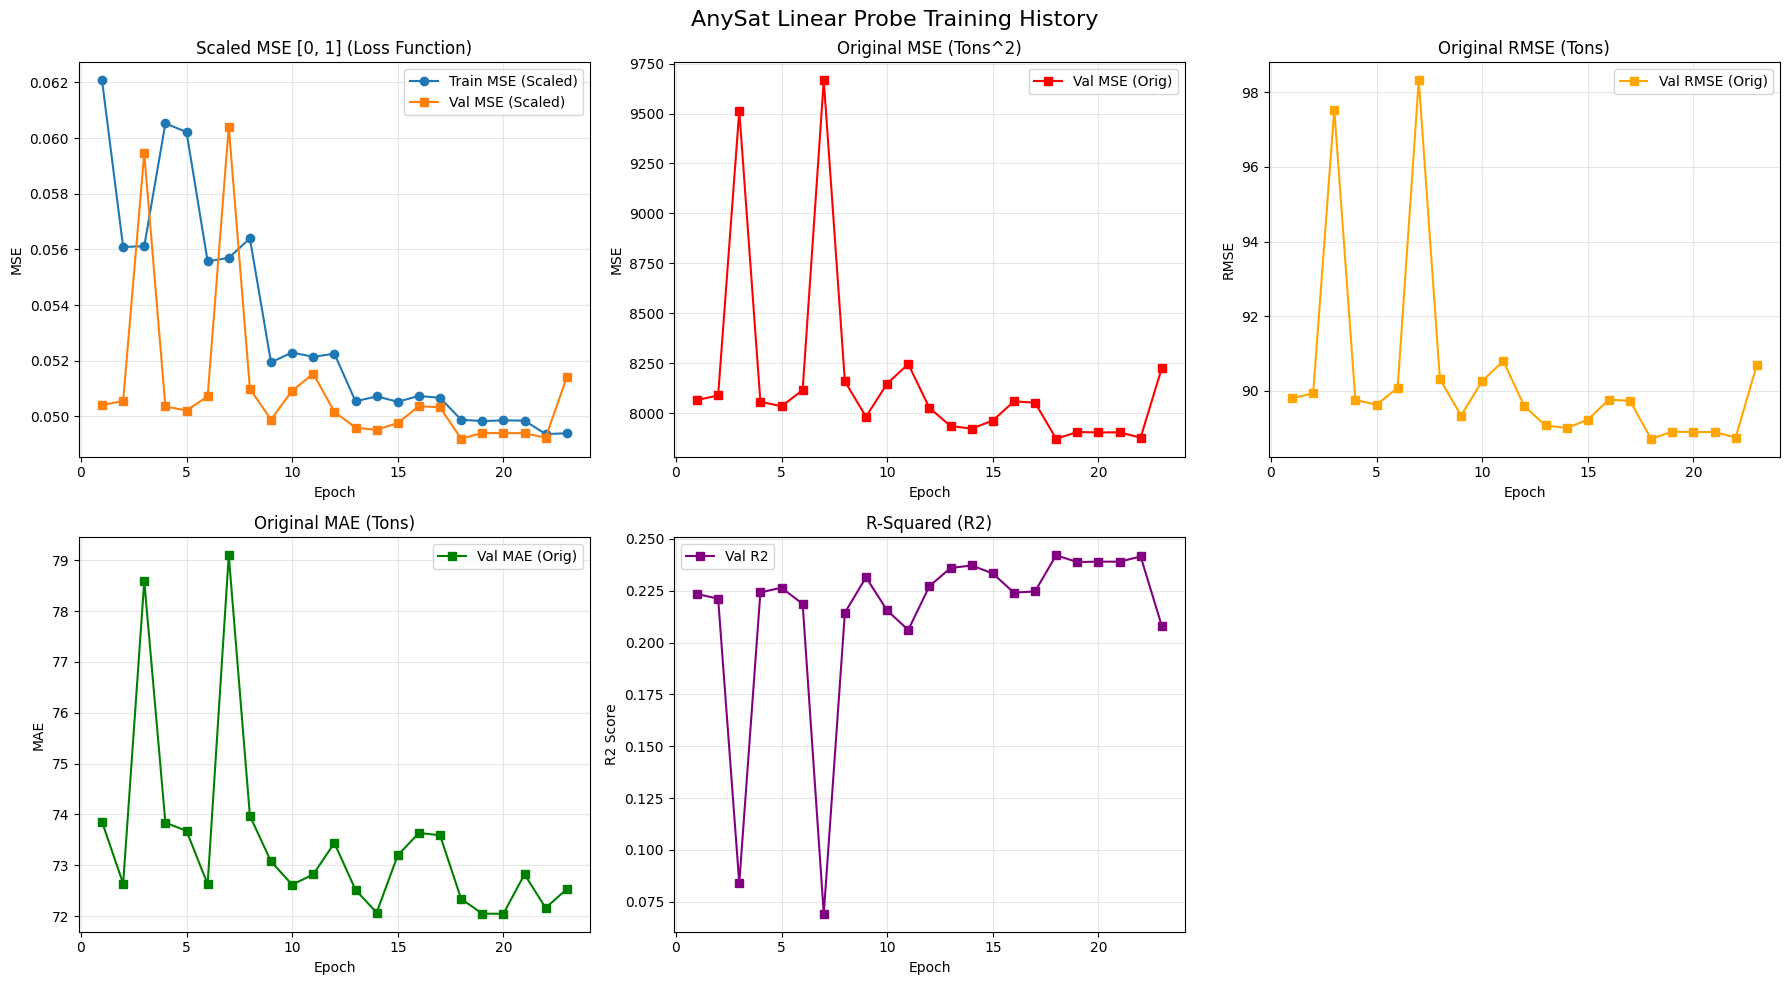

In [ ]:
# Cell 7: Plotting Metrics
history_df = pd.read_csv(history_path)

# Change to a 2x3 grid to fit 5 plots
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('AnySat Linear Probe Training History', fontsize=16)

# 1. Scaled MSE Plot (Training Dynamics)
axs[0, 0].plot(history_df['epoch'], history_df['train_mse_scaled'], label='Train MSE (Scaled)', marker='o')
axs[0, 0].plot(history_df['epoch'], history_df['val_mse_scaled'], label='Val MSE (Scaled)', marker='s')
axs[0, 0].set_title('Scaled MSE [0, 1] (Loss Function)')
axs[0, 0].set_xlabel('Epoch')
axs[0, 0].set_ylabel('MSE')
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# 2. Original MSE Plot
axs[0, 1].plot(history_df['epoch'], history_df['val_mse_orig'], label='Val MSE (Orig)', color='red', marker='s')
axs[0, 1].set_title('Original MSE (Tons^2)')
axs[0, 1].set_xlabel('Epoch')
axs[0, 1].set_ylabel('MSE')
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# 3. Original RMSE Plot
axs[0, 2].plot(history_df['epoch'], history_df['val_rmse_orig'], label='Val RMSE (Orig)', color='orange', marker='s')
axs[0, 2].set_title('Original RMSE (Tons)')
axs[0, 2].set_xlabel('Epoch')
axs[0, 2].set_ylabel('RMSE')
axs[0, 2].legend()
axs[0, 2].grid(True, alpha=0.3)

# 4. Original MAE Plot
axs[1, 0].plot(history_df['epoch'], history_df['val_mae_orig'], label='Val MAE (Orig)', color='green', marker='s')
axs[1, 0].set_title('Original MAE (Tons)')
axs[1, 0].set_xlabel('Epoch')
axs[1, 0].set_ylabel('MAE')
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# 5. R2 Plot
axs[1, 1].plot(history_df['epoch'], history_df['val_r2'], label='Val R2', color='purple', marker='s')
axs[1, 1].set_title('R-Squared (R2)')
axs[1, 1].set_xlabel('Epoch')
axs[1, 1].set_ylabel('R2 Score')
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3)

# 6. Hide the empty 6th subplot
fig.delaxes(axs[1, 2])

plt.tight_layout()
plot_output_path = os.path.join(config.drive_output_dir, config.plot_file)
plt.savefig(plot_output_path, dpi=300)
print(f"Plot successfully saved to {plot_output_path}")
plt.show()

In [ ]:
# Cell 8: Auto-Disconnect Runtime
from google.colab import runtime

print("Pipeline executed successfully. Disconnecting runtime to save compute units...")
# Uncomment the line below when you are ready to use the auto-disconnect feature
# runtime.unassign()

Pipeline executed successfully. Disconnecting runtime to save compute units...
